# 04 · Modeling

**Project:** Credit Default Risk — AI Governance Portfolio (Notebook 4 of the pipeline)

---

## Goal

Train and compare three classifiers on the processed matrix from `03`, then choose a
**decision threshold from business cost** rather than the arbitrary 0.5. For a high-risk
credit model, *the threshold is itself a governance decision*: it sets how many defaulters
you catch versus how many good customers you wrongly reject.

### Approach to the 8% imbalance (a deliberate, documented choice)
We **do not resample or reweight** the training data. Instead we train on the natural
distribution so the model's predicted probabilities stay **calibrated to the true ~8% base
rate**, then handle the imbalance *at the decision stage* by picking a **cost-optimal
threshold**. This keeps the probabilities meaningful and the operating point transparent —
both valuable for an auditable model.

### Steps
1. Load the processed train/validation matrices.
2. Establish **why accuracy is the wrong metric**.
3. Train **Logistic Regression / Random Forest / XGBoost**; compare on **PR-AUC / ROC-AUC**.
4. Tune a **cost-sensitive threshold** (FN : FP = 10 : 1) and sanity-check it against the
   analytical Bayes-optimal threshold.
5. Report the confusion matrix, recall, and **feature importance**.
6. Save the model + validation predictions for the Fair Lending audit (`05`).


## 0 · Setup & load processed data

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROC_DIR = "../data/processed"
RESULTS_DIR = "../results"
MODELS_DIR = "../models"                 # trained models (git-ignored)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Load the matrices from 03. Downcast features to float32 to halve memory/load time.
X_train = pd.read_csv(os.path.join(PROC_DIR, "X_train.csv"), index_col=0).astype("float32")
X_val = pd.read_csv(os.path.join(PROC_DIR, "X_val.csv"), index_col=0).astype("float32")
y_train = pd.read_csv(os.path.join(PROC_DIR, "y_train.csv"), index_col=0)["TARGET"]
y_val = pd.read_csv(os.path.join(PROC_DIR, "y_val.csv"), index_col=0)["TARGET"]

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("Train default rate:", f"{y_train.mean()*100:.2f}%", "| Val:", f"{y_val.mean()*100:.2f}%")

X_train: (246008, 96) | X_val: (61503, 96)
Train default rate: 8.07% | Val: 8.07%


## 1 · Why not accuracy?

With only 8% defaulters, a model that predicts *"everyone repays"* scores **92% accuracy**
and catches **zero** defaulters — useless and dangerous. So we judge models on:
- **PR-AUC** (average precision) — performance on the rare positive class; our primary metric.
- **ROC-AUC** — overall ranking quality.
- **Recall on defaulters** — the share of real defaulters we catch (the costly errors to miss).


In [2]:
# The "predict majority" baseline makes the point concretely.
naive_accuracy = (y_val == 0).mean()
print(f"Naive 'everyone repays' accuracy: {naive_accuracy*100:.2f}%  (but recall on defaulters = 0%)")

Naive 'everyone repays' accuracy: 91.93%  (but recall on defaulters = 0%)


## 2 · Train three models (natural distribution)

We train on the raw class distribution — **no class weighting or resampling** — so the
predicted probabilities remain calibrated to the true base rate (essential for the
cost-based threshold in §4). Logistic Regression is a transparent linear baseline; Random
Forest and XGBoost capture the non-linear interactions typical of tabular credit data.


In [3]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=12, n_jobs=-1, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr", n_jobs=-1, random_state=42),
}

# Fit each model and store its predicted probabilities on the validation set.
val_proba = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_proba[name] = model.predict_proba(X_val)[:, 1]   # P(default)
    print(f"trained {name}  (val P(default): mean {val_proba[name].mean():.3f})")

trained LogisticRegression  (val P(default): mean 0.080)


trained RandomForest  (val P(default): mean 0.080)


trained XGBoost  (val P(default): mean 0.080)


## 3 · Compare models — PR-AUC & ROC-AUC

                    PR_AUC  ROC_AUC
model                              
XGBoost             0.2826   0.7808
RandomForest        0.2536   0.7623
LogisticRegression  0.2436   0.7585


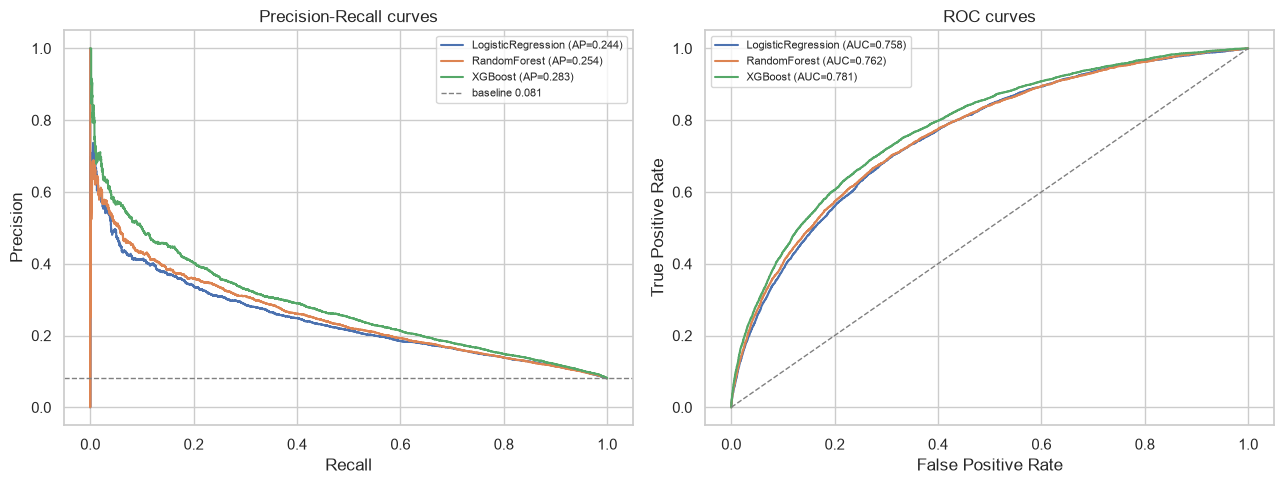

In [4]:
# Score every model on the two imbalance-aware metrics.
scores = []
for name, proba in val_proba.items():
    scores.append({
        "model": name,
        "PR_AUC": average_precision_score(y_val, proba),
        "ROC_AUC": roc_auc_score(y_val, proba),
    })
scores = pd.DataFrame(scores).set_index("model").sort_values("PR_AUC", ascending=False)
print(scores.round(4).to_string())

# Plot PR and ROC curves for all three.
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, proba in val_proba.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ax[0].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_val, proba):.3f})")
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_val, proba):.3f})")
ax[0].axhline(y_val.mean(), color="gray", ls="--", lw=1, label=f"baseline {y_val.mean():.3f}")
ax[0].set(title="Precision-Recall curves", xlabel="Recall", ylabel="Precision"); ax[0].legend(fontsize=8)
ax[1].plot([0, 1], [0, 1], color="gray", ls="--", lw=1)
ax[1].set(title="ROC curves", xlabel="False Positive Rate", ylabel="True Positive Rate"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "04_model_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()

**Interpretation.** We select the model with the highest **PR-AUC** (best at ranking the
rare defaulters). On this tabular, non-linear problem **XGBoost wins** (PR-AUC ≈ 0.28 vs the
0.08 baseline — roughly 3.5× better than random at surfacing defaulters). It carries forward
to threshold tuning.


In [5]:
# Select the best model by PR-AUC.
best_name = scores.index[0]
best_proba = val_proba[best_name]
best_model = models[best_name]
print("Selected model:", best_name)

Selected model: XGBoost


## 4 · Cost-sensitive threshold (the governance decision)

The default 0.5 cut-off assumes a false negative and a false positive cost the same. They
do not. We encode the business reality and pick the threshold that **minimizes total cost**.

- **False Negative (FN)** — approve a loan that defaults → lose principal. **Expensive.**
- **False Positive (FP)** — reject a good applicant → lose the interest margin + goodwill.

We set **`COST_FN : COST_FP = 10 : 1`** (a documented, configurable business assumption). For
calibrated probabilities the cost-minimizing cut-off has a known analytical form, the
**Bayes-optimal threshold = `COST_FP / (COST_FP + COST_FN)`**, which we use to sanity-check
the empirical sweep. A real deployment would calibrate the ratio with the lending team — and
the fairness audit (`05`) checks the chosen threshold doesn't impose unequal error costs
across protected groups.


Cost-optimal threshold (empirical): 0.10
Bayes-optimal threshold (analytical): 0.091   <- should be close
Default threshold: 0.50


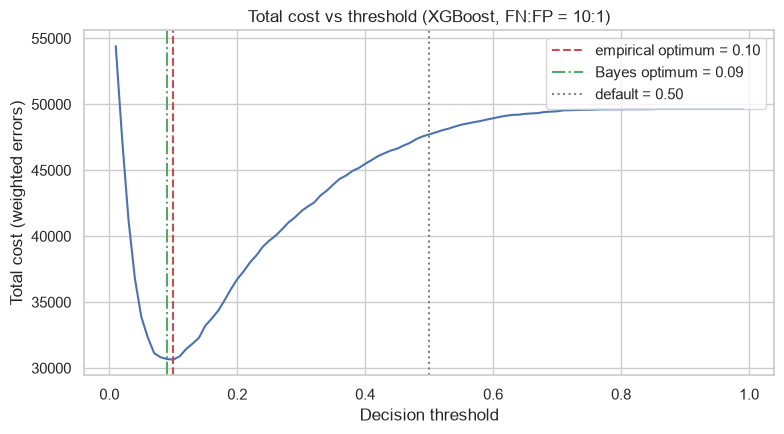

In [6]:
COST_FN = 10    # cost of missing a true defaulter
COST_FP = 1     # cost of a false alarm on a good applicant

# Sweep candidate thresholds and compute total expected cost at each.
thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    costs.append(fn * COST_FN + fp * COST_FP)
costs = np.array(costs)

best_t = thresholds[costs.argmin()]                       # empirical cost-minimizing threshold
bayes_t = COST_FP / (COST_FP + COST_FN)                   # analytical optimum for calibrated probs
default_t = 0.5
print(f"Cost-optimal threshold (empirical): {best_t:.2f}")
print(f"Bayes-optimal threshold (analytical): {bayes_t:.3f}   <- should be close")
print(f"Default threshold: {default_t:.2f}")

# Visualize the cost curve.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, costs, color="#4C72B0")
ax.axvline(best_t, color="#C44E52", ls="--", label=f"empirical optimum = {best_t:.2f}")
ax.axvline(bayes_t, color="#55A868", ls="-.", label=f"Bayes optimum = {bayes_t:.2f}")
ax.axvline(default_t, color="gray", ls=":", label="default = 0.50")
ax.set(title=f"Total cost vs threshold ({best_name}, FN:FP = {COST_FN}:{COST_FP})",
       xlabel="Decision threshold", ylabel="Total cost (weighted errors)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "04_cost_threshold.png"), dpi=120, bbox_inches="tight")
plt.show()

## 5 · Performance at the chosen threshold

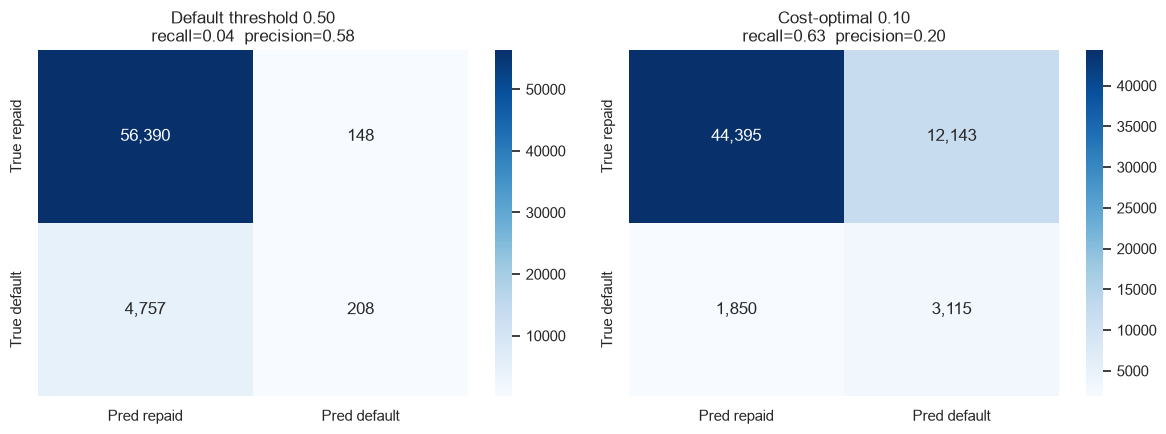

Classification report @ threshold 0.10 (XGBoost):

              precision    recall  f1-score   support

      repaid       0.96      0.79      0.86     56538
     default       0.20      0.63      0.31      4965

    accuracy                           0.77     61503
   macro avg       0.58      0.71      0.59     61503
weighted avg       0.90      0.77      0.82     61503



In [7]:
# Compare the confusion matrix at the default vs the cost-optimal threshold.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, t, title in [(axes[0], default_t, "Default threshold 0.50"),
                     (axes[1], best_t, f"Cost-optimal {best_t:.2f}")]:
    pred = (best_proba >= t).astype(int)
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                xticklabels=["Pred repaid", "Pred default"],
                yticklabels=["True repaid", "True default"])
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) else 0
    ax.set_title(f"{title}\nrecall={recall:.2f}  precision={precision:.2f}")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "04_confusion_matrices.png"), dpi=120, bbox_inches="tight")
plt.show()

# Full classification report at the chosen threshold.
pred_best = (best_proba >= best_t).astype(int)
print(f"Classification report @ threshold {best_t:.2f} ({best_name}):\n")
print(classification_report(y_val, pred_best, target_names=["repaid", "default"]))

**Interpretation.** At the **default 0.50** the model catches almost no defaulters
(recall ≈ 0.04) — because with calibrated probabilities very few applicants exceed 50%
default probability. Moving to the **cost-optimal ≈ 0.10** raises **recall to ≈ 0.63**: we now
catch most real defaulters, accepting more false alarms because each one is 10× cheaper than
a missed default. This swing is precisely the **governance decision** the cost ratio encodes —
and why the threshold, not raw accuracy, is what we document and defend.


## 6 · What drives the model?

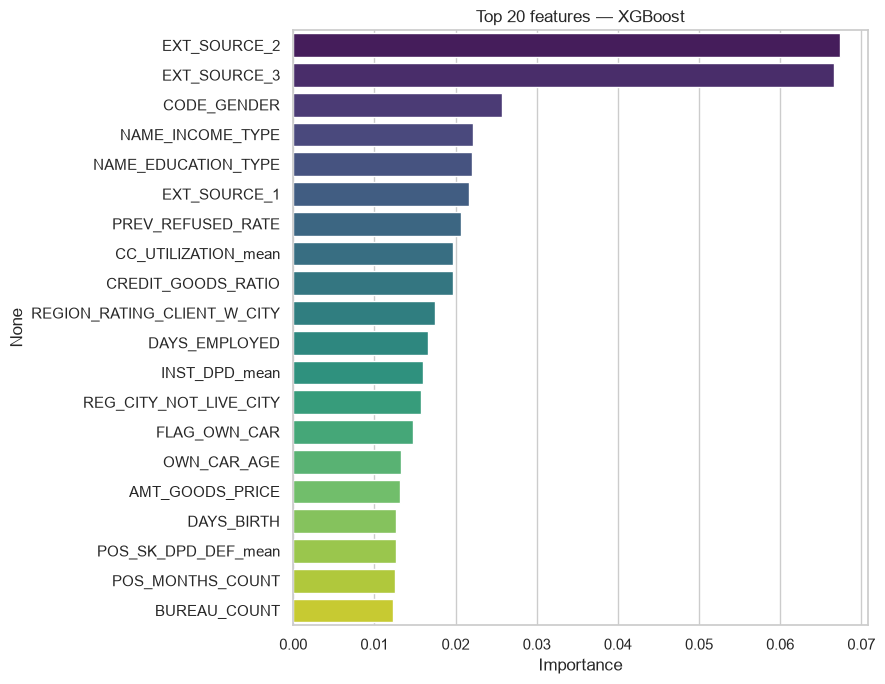

Top 10 features:
 EXT_SOURCE_2                   0.0674
EXT_SOURCE_3                   0.0667
CODE_GENDER                    0.0257
NAME_INCOME_TYPE               0.0222
NAME_EDUCATION_TYPE            0.0220
EXT_SOURCE_1                   0.0217
PREV_REFUSED_RATE              0.0207
CC_UTILIZATION_mean            0.0197
CREDIT_GOODS_RATIO             0.0196
REGION_RATING_CLIENT_W_CITY    0.0174


In [8]:
# Feature importance (only available for the tree models).
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top = importance.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.barplot(x=top.values, y=top.index, ax=ax, palette="viridis")
    ax.set(title=f"Top 20 features — {best_name}", xlabel="Importance")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "04_feature_importance.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print("Top 10 features:\n", top.head(10).round(4).to_string())
else:
    print(best_name, "does not expose feature_importances_")

**⚠️ Governance flag.** `CODE_GENDER` and `NAME_EDUCATION_TYPE` rank among the **top
features**, and age enters via `DAYS_EMPLOYED` / employment tenure. These are **protected
attributes / proxies** under ECOA — a model leaning on them is a Fair Lending risk. The audit
in `05` quantifies the resulting disparity and tests a variant with `CODE_GENDER` removed to
measure the performance-vs-fairness trade-off.


## 7 · Save model & validation predictions for the audit

In [9]:
# Persist the trained model (git-ignored, regenerable).
joblib.dump(best_model, os.path.join(MODELS_DIR, "best_model.joblib"))

# Save validation predictions aligned to the same index as protected_val.csv,
# so 05 can join predictions to protected groups and slice fairness metrics.
val_pred_df = pd.DataFrame({
    "y_true": y_val,
    "proba": best_proba,
    "pred": pred_best,
}, index=X_val.index)
val_pred_df.to_csv(os.path.join(PROC_DIR, "val_predictions.csv"))

# Save the chosen threshold + metadata for reproducibility.
pd.Series({"model": best_name, "threshold": best_t,
           "COST_FN": COST_FN, "COST_FP": COST_FP,
           "PR_AUC": scores.loc[best_name, "PR_AUC"],
           "ROC_AUC": scores.loc[best_name, "ROC_AUC"]}).to_csv(
    os.path.join(PROC_DIR, "model_metadata.csv"))

print("Saved: models/best_model.joblib, data/processed/val_predictions.csv, model_metadata.csv")

Saved: models/best_model.joblib, data/processed/val_predictions.csv, model_metadata.csv


## 8 · Key takeaways & next step

1. **Accuracy is rejected** as a metric; PR-AUC / recall drive selection.
2. Three models trained on the **natural distribution** (no reweighting) to keep
   probabilities calibrated; **XGBoost wins** on PR-AUC (≈0.28).
3. **Threshold set from business cost** (FN:FP = 10:1) → ≈0.10, matching the analytical
   Bayes optimum, lifting **recall from ≈0.04 to ≈0.63** — the core governance decision.
4. Feature importance shows **protected-attribute proxies** (gender, education) among the top
   drivers → flagged for the Fair Lending audit.
5. Saved the model + validation predictions, aligned to the protected-attribute snapshot.

**Artifacts:** `results/04_model_comparison.png`, `04_cost_threshold.png`,
`04_confusion_matrices.png`, `04_feature_importance.png`; `models/best_model.joblib`.

---
### ➡️ Next: `05_evaluation_fairlending`
Slice the validation predictions by the **protected groups** from `03`: compute
**disparate impact, equal-opportunity, and FPR/FNR gaps** across gender, age, family status,
and education — the core Fair Lending audit and the project's differentiator.
